# Model Interpretation and Robustness Analysis

This notebook evaluates feature importance, proportional error by road,
and the chronological robustness of the Random Forest forecasting model.

In [24]:
import os
import io
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [25]:
print("Upload: random_forest_next_hour_traffic_model.joblib")

uploaded_model = files.upload()

Upload: random_forest_next_hour_traffic_model.joblib


Saving random_forest_next_hour_traffic_model.joblib to random_forest_next_hour_traffic_model (2).joblib


In [26]:
print("Upload: selected_delhi_roads_hourly.csv")

uploaded_dataset = files.upload()

Upload: selected_delhi_roads_hourly.csv


Saving selected_delhi_roads_hourly.csv to selected_delhi_roads_hourly (1).csv


In [27]:
print("Upload: random_forest_per_road_metrics.csv")

uploaded_metrics = files.upload()

Upload: random_forest_per_road_metrics.csv


Saving random_forest_per_road_metrics.csv to random_forest_per_road_metrics (1).csv


In [28]:
required_files = [
    "random_forest_next_hour_traffic_model.joblib",
    "selected_delhi_roads_hourly.csv",
    "random_forest_per_road_metrics.csv"
]

print("FILES IN COLAB")
print("=" * 60)

for filename in required_files:
    if os.path.exists(filename):
        file_size = os.path.getsize(filename)

        print(
            f"[FOUND] {filename} "
            f"({file_size:,} bytes)"
        )
    else:
        print(f"[MISSING] {filename}")

FILES IN COLAB
[FOUND] random_forest_next_hour_traffic_model.joblib (42,664,954 bytes)
[FOUND] selected_delhi_roads_hourly.csv (376,264 bytes)
[FOUND] random_forest_per_road_metrics.csv (980 bytes)


In [29]:
MODEL_FILE = (
    "random_forest_next_hour_traffic_model.joblib"
)

DATASET_FILE = (
    "selected_delhi_roads_hourly.csv"
)

ROAD_METRICS_FILE = (
    "random_forest_per_road_metrics.csv"
)

# Load the trained pipeline.
random_forest_pipeline = joblib.load(
    MODEL_FILE
)

# Load the processed road-hour dataset.
traffic_df = pd.read_csv(
    DATASET_FILE
)

# Load the existing per-road validation results.
road_metrics_df = pd.read_csv(
    ROAD_METRICS_FILE
)

print("UPLOAD AND LOADING CHECK")
print("=" * 60)

print(
    "Dataset shape:",
    traffic_df.shape
)

print(
    "Number of roads:",
    traffic_df["street_name"].nunique()
)

print(
    "Date coverage:",
    traffic_df["date"].min(),
    "to",
    traffic_df["date"].max()
)

print(
    "Per-road metrics shape:",
    road_metrics_df.shape
)

print(
    "Loaded model type:",
    type(random_forest_pipeline).__name__
)

print(
    "Pipeline steps:",
    list(
        random_forest_pipeline.named_steps.keys()
    )
)

UPLOAD AND LOADING CHECK
Dataset shape: (4800, 12)
Number of roads: 10
Date coverage: 2024-08-11 to 2024-08-30
Per-road metrics shape: (10, 6)
Loaded model type: Pipeline
Pipeline steps: ['preprocessor', 'model']


In [30]:
# Extract the preprocessing and Random Forest components.
preprocessor = random_forest_pipeline.named_steps[
    "preprocessor"
]

random_forest_model = random_forest_pipeline.named_steps[
    "model"
]

# Confirm that the model supports feature importance.
if not hasattr(
    random_forest_model,
    "feature_importances_"
):
    raise TypeError(
        "The loaded model does not provide feature importances."
    )

# Obtain the transformed feature names.
try:
    transformed_feature_names = (
        preprocessor.get_feature_names_out()
    )
except Exception:
    transformed_feature_names = np.array([
        f"feature_{number + 1}"
        for number in range(
            len(
                random_forest_model.feature_importances_
            )
        )
    ])

feature_importance_values = (
    random_forest_model.feature_importances_
)

if (
    len(transformed_feature_names)
    != len(feature_importance_values)
):
    raise ValueError(
        "The number of feature names does not match "
        "the number of feature-importance values."
    )

feature_importance_detailed_df = pd.DataFrame({
    "transformed_feature": transformed_feature_names,
    "importance": feature_importance_values
})

# Remove prefixes such as numeric__ and categorical__.
feature_importance_detailed_df[
    "feature"
] = (
    feature_importance_detailed_df[
        "transformed_feature"
    ]
    .str.replace(
        r"^[^_]+__",
        "",
        regex=True
    )
)

feature_importance_detailed_df = (
    feature_importance_detailed_df
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

print("DETAILED FEATURE IMPORTANCE")
print("=" * 70)

display(
    feature_importance_detailed_df[
        ["feature", "importance"]
    ].head(20)
)

print(
    "\nTotal importance:",
    round(
        feature_importance_detailed_df[
            "importance"
        ].sum(),
        6
    )
)

DETAILED FEATURE IMPORTANCE


,feature,importance
0,probe_count,0.971038
1,target_hour,0.008800
2,rolling_mean_3,0.006204
3,lag_1,0.005671
4,rolling_mean_24,0.003835
5,lag_24,0.001652
6,target_day_number,0.000768
7,target_is_peak_hour,0.000513
8,average_speed_limit,0.000254
9,average_frc,0.000242



Total importance: 1.0


In [31]:
def create_grouped_feature_name(
    feature_name
):
    """
    Combine one-hot encoded street-name features while
    preserving the other feature names.
    """

    if feature_name.startswith(
        "street_name_"
    ):
        return "street_name"

    return feature_name


feature_importance_detailed_df[
    "grouped_feature"
] = (
    feature_importance_detailed_df[
        "feature"
    ].apply(
        create_grouped_feature_name
    )
)

feature_importance_grouped_df = (
    feature_importance_detailed_df
    .groupby(
        "grouped_feature",
        as_index=False
    )["importance"]
    .sum()
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

feature_importance_grouped_df[
    "importance_percentage"
] = (
    feature_importance_grouped_df[
        "importance"
    ]
    * 100
)

print("GROUPED FEATURE IMPORTANCE")
print("=" * 70)

display(
    feature_importance_grouped_df.round(4)
)

GROUPED FEATURE IMPORTANCE


,grouped_feature,importance,importance_percentage
0,probe_count,0.9710,97.1038
1,target_hour,0.0088,0.8800
2,rolling_mean_3,0.0062,0.6204
3,lag_1,0.0057,0.5671
4,rolling_mean_24,0.0038,0.3835
5,lag_24,0.0017,0.1652
6,target_day_number,0.0008,0.0768
7,target_is_peak_hour,0.0005,0.0513
8,street_name,0.0005,0.0479
9,average_speed_limit,0.0003,0.0254


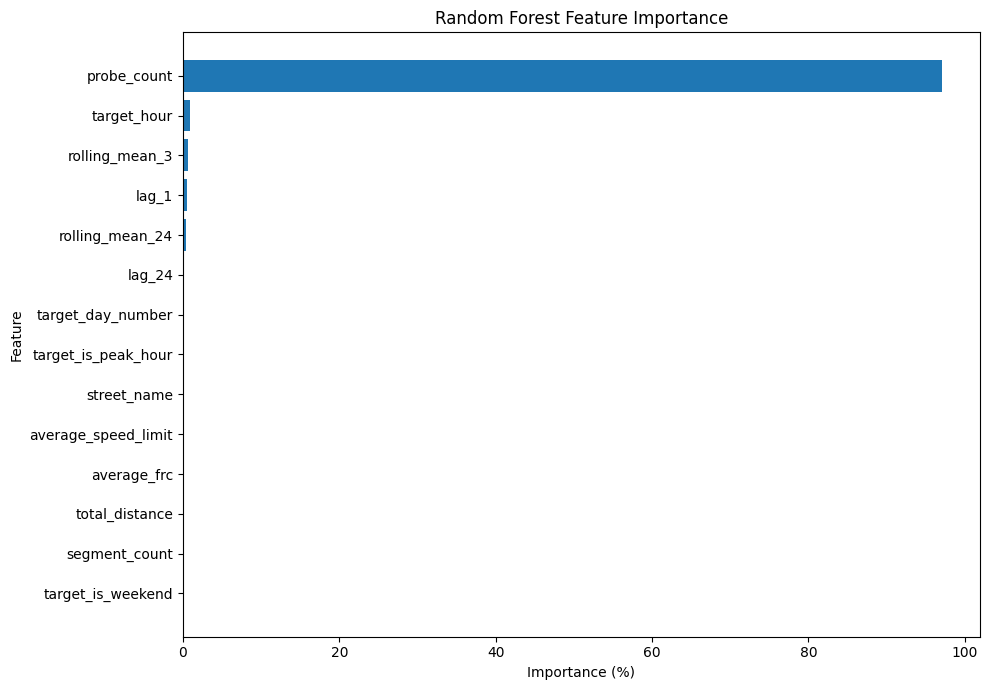

In [32]:
# Select the fifteen most influential grouped features.
top_features = (
    feature_importance_grouped_df
    .head(15)
    .sort_values(
        "importance_percentage",
        ascending=True
    )
)

plt.figure(
    figsize=(10, 7)
)

plt.barh(
    top_features["grouped_feature"],
    top_features["importance_percentage"]
)

plt.title(
    "Random Forest Feature Importance"
)

plt.xlabel(
    "Importance (%)"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()

plt.savefig(
    "figure_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [33]:
feature_importance_grouped_df.to_csv(
    "feature_importance_results.csv",
    index=False
)

feature_importance_detailed_df.to_csv(
    "feature_importance_detailed.csv",
    index=False
)

print("Saved files:")
print(
    "1. feature_importance_results.csv"
)
print(
    "2. feature_importance_detailed.csv"
)
print(
    "3. figure_feature_importance.png"
)

Saved files:
1. feature_importance_results.csv
2. feature_importance_detailed.csv
3. figure_feature_importance.png


In [34]:
feature_check_df = pd.read_csv(
    "feature_importance_results.csv"
)

print("FEATURE-IMPORTANCE CHECK")
print("=" * 60)

display(
    feature_check_df.head(10).round(4)
)

print(
    "Number of grouped features:",
    len(feature_check_df)
)

print(
    "Total importance percentage:",
    round(
        feature_check_df[
            "importance_percentage"
        ].sum(),
        4
    )
)

FEATURE-IMPORTANCE CHECK


,grouped_feature,importance,importance_percentage
0,probe_count,0.9710,97.1038
1,target_hour,0.0088,0.8800
2,rolling_mean_3,0.0062,0.6204
3,lag_1,0.0057,0.5671
4,rolling_mean_24,0.0038,0.3835
5,lag_24,0.0017,0.1652
6,target_day_number,0.0008,0.0768
7,target_is_peak_hour,0.0005,0.0513
8,street_name,0.0005,0.0479
9,average_speed_limit,0.0003,0.0254


Number of grouped features: 14
Total importance percentage: 100.0


In [35]:
print("PER-ROAD METRICS COLUMNS")
print("=" * 60)

print(
    road_metrics_df.columns.tolist()
)

display(
    road_metrics_df.round(4)
)

PER-ROAD METRICS COLUMNS
['street_name', 'records', 'MAE', 'RMSE', 'R2', 'WAPE_Percentage']


,street_name,records,MAE,RMSE,R2,WAPE_Percentage
0,Africa Avenue,96,2420.2374,3444.4007,0.9590,7.9167
1,Mehrauli Badarpur Road,96,2681.2182,3515.9678,0.9614,7.3772
2,Vikas Marg,96,2704.1027,3476.8285,0.9251,7.4024
3,Noida Link Road,96,2723.4452,3713.1075,0.9457,8.4826
4,Sardar Patel Marg,96,3600.4215,4741.9208,0.9408,7.5504
5,Aurobindo Marg,96,5784.3541,7777.5729,0.9785,5.1916
6,Barapullah Road,96,5934.5472,8393.7606,0.9448,8.6402
7,Mathura Road,96,7379.4361,9489.9597,0.9803,5.1334
8,Outer Ring Road,96,15029.6955,19698.4398,0.9654,6.2984
9,Mahatma Gandhi Marg,96,20892.7793,27767.2176,0.9704,5.5547


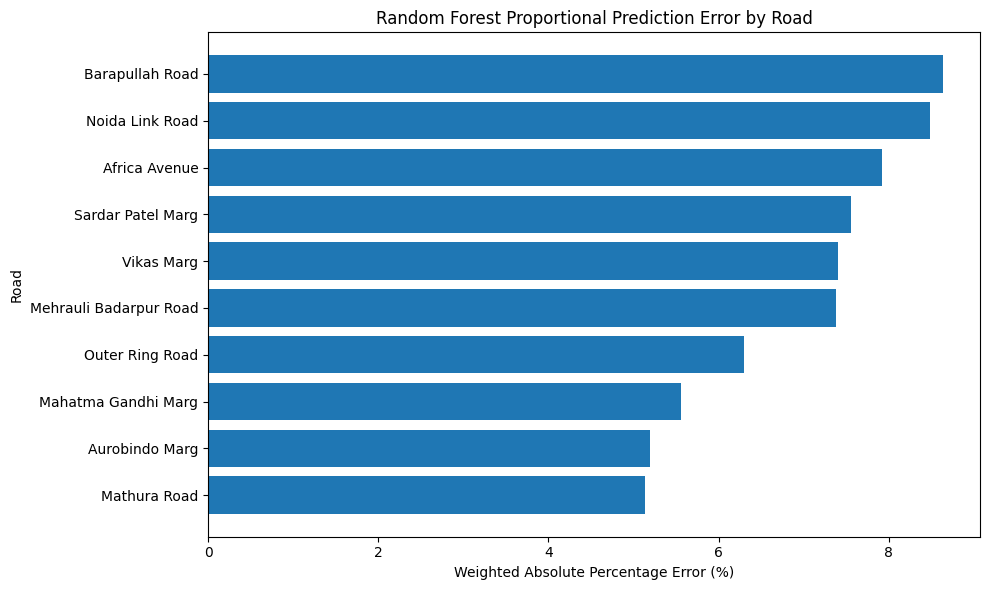

In [36]:
required_wape_columns = {
    "street_name",
    "WAPE_Percentage"
}

missing_wape_columns = (
    required_wape_columns
    - set(road_metrics_df.columns)
)

if missing_wape_columns:
    raise ValueError(
        "Missing required columns: "
        + str(missing_wape_columns)
    )

wape_plot_df = (
    road_metrics_df
    .sort_values(
        "WAPE_Percentage",
        ascending=True
    )
)

plt.figure(
    figsize=(10, 6)
)

plt.barh(
    wape_plot_df["street_name"],
    wape_plot_df["WAPE_Percentage"]
)

plt.title(
    "Random Forest Proportional Prediction Error by Road"
)

plt.xlabel(
    "Weighted Absolute Percentage Error (%)"
)

plt.ylabel(
    "Road"
)

plt.tight_layout()

plt.savefig(
    "figure_wape_by_road.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [37]:
wape_results_df = (
    road_metrics_df[
        [
            "street_name",
            "records",
            "MAE",
            "RMSE",
            "R2",
            "WAPE_Percentage"
        ]
    ]
    .sort_values(
        "WAPE_Percentage",
        ascending=True
    )
    .reset_index(drop=True)
)

wape_results_df.to_csv(
    "wape_by_road_results.csv",
    index=False
)

print("WAPE RESULTS")
print("=" * 60)

display(
    wape_results_df.round(4)
)

print("\nSaved files:")
print("1. figure_wape_by_road.png")
print("2. wape_by_road_results.csv")

WAPE RESULTS


,street_name,records,MAE,RMSE,R2,WAPE_Percentage
0,Mathura Road,96,7379.4361,9489.9597,0.9803,5.1334
1,Aurobindo Marg,96,5784.3541,7777.5729,0.9785,5.1916
2,Mahatma Gandhi Marg,96,20892.7793,27767.2176,0.9704,5.5547
3,Outer Ring Road,96,15029.6955,19698.4398,0.9654,6.2984
4,Mehrauli Badarpur Road,96,2681.2182,3515.9678,0.9614,7.3772
5,Vikas Marg,96,2704.1027,3476.8285,0.9251,7.4024
6,Sardar Patel Marg,96,3600.4215,4741.9208,0.9408,7.5504
7,Africa Avenue,96,2420.2374,3444.4007,0.9590,7.9167
8,Noida Link Road,96,2723.4452,3713.1075,0.9457,8.4826
9,Barapullah Road,96,5934.5472,8393.7606,0.9448,8.6402



Saved files:
1. figure_wape_by_road.png
2. wape_by_road_results.csv


## Expanding-Window Chronological Validation

The Random Forest model is retrained using progressively larger historical
training periods and evaluated on later, unseen dates.

In [38]:
# Create the datetime column and arrange every road chronologically.
validation_df = traffic_df.copy()

validation_df["datetime"] = (
    pd.to_datetime(validation_df["date"])
    + pd.to_timedelta(
        validation_df["hour"],
        unit="h"
    )
)

validation_df = (
    validation_df
    .sort_values(
        ["street_name", "datetime"]
    )
    .reset_index(drop=True)
)

validation_grouped = validation_df.groupby(
    "street_name",
    group_keys=False
)

# Historical traffic features.
validation_df["lag_1"] = (
    validation_grouped["probe_count"]
    .shift(1)
)

validation_df["lag_24"] = (
    validation_grouped["probe_count"]
    .shift(24)
)

validation_df["rolling_mean_3"] = (
    validation_grouped["probe_count"]
    .transform(
        lambda series:
        series.shift(1).rolling(3).mean()
    )
)

validation_df["rolling_mean_24"] = (
    validation_grouped["probe_count"]
    .transform(
        lambda series:
        series.shift(1).rolling(24).mean()
    )
)

# Next-hour forecasting target.
validation_df["target_next_hour"] = (
    validation_grouped["probe_count"]
    .shift(-1)
)

validation_df["target_datetime"] = (
    validation_df["datetime"]
    + pd.Timedelta(hours=1)
)

validation_df["target_hour"] = (
    validation_df["target_datetime"].dt.hour
)

validation_df["target_day_number"] = (
    validation_df["target_datetime"].dt.dayofweek
)

validation_df["target_is_weekend"] = (
    validation_df["target_day_number"] >= 5
).astype(int)

validation_df["target_is_peak_hour"] = (
    validation_df["target_hour"]
    .isin(
        [7, 8, 9, 17, 18, 19, 20]
    )
    .astype(int)
)

validation_model_df = (
    validation_df
    .dropna(
        subset=[
            "lag_1",
            "lag_24",
            "rolling_mean_3",
            "rolling_mean_24",
            "target_next_hour"
        ]
    )
    .copy()
)

print("VALIDATION DATASET CHECK")
print("=" * 70)

print(
    "Model-ready records:",
    len(validation_model_df)
)

print(
    "First target:",
    validation_model_df[
        "target_datetime"
    ].min()
)

print(
    "Last target:",
    validation_model_df[
        "target_datetime"
    ].max()
)

print(
    "Number of roads:",
    validation_model_df[
        "street_name"
    ].nunique()
)

VALIDATION DATASET CHECK
Model-ready records: 4550
First target: 2024-08-12 01:00:00
Last target: 2024-08-30 23:00:00
Number of roads: 10


In [39]:
categorical_features = [
    "street_name"
]

numeric_features = [
    "probe_count",
    "lag_1",
    "lag_24",
    "rolling_mean_3",
    "rolling_mean_24",
    "target_hour",
    "target_day_number",
    "target_is_weekend",
    "target_is_peak_hour",
    "segment_count",
    "average_speed_limit",
    "average_frc",
    "total_distance"
]

feature_columns = (
    categorical_features
    + numeric_features
)


def create_random_forest_pipeline():
    """
    Create a fresh preprocessing and Random Forest pipeline
    for each chronological validation run.
    """

    fold_preprocessor = ColumnTransformer(
        transformers=[
            (
                "road",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                ),
                categorical_features
            ),
            (
                "numeric",
                "passthrough",
                numeric_features
            )
        ]
    )

    fold_model = RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )

    return Pipeline(
        steps=[
            (
                "preprocessor",
                fold_preprocessor
            ),
            (
                "model",
                fold_model
            )
        ]
    )


def calculate_metrics(
    actual,
    predicted
):
    """Calculate the forecasting evaluation metrics."""

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = (
        mean_squared_error(
            actual,
            predicted
        )
        ** 0.5
    )

    r2 = r2_score(
        actual,
        predicted
    )

    actual_total = np.abs(actual).sum()

    wape = (
        np.abs(
            actual - predicted
        ).sum()
        / actual_total
        * 100
        if actual_total != 0
        else np.nan
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "WAPE_Percentage": wape
    }


print("Model pipeline function prepared.")

Model pipeline function prepared.


In [40]:
validation_periods = [
    {
        "run": "Validation 1",
        "train_end": "2024-08-23 00:00:00",
        "test_start": "2024-08-23 00:00:00",
        "test_end": "2024-08-25 00:00:00"
    },
    {
        "run": "Validation 2",
        "train_end": "2024-08-25 00:00:00",
        "test_start": "2024-08-25 00:00:00",
        "test_end": "2024-08-27 00:00:00"
    },
    {
        "run": "Final Validation",
        "train_end": "2024-08-27 00:00:00",
        "test_start": "2024-08-27 00:00:00",
        "test_end": "2024-08-31 00:00:00"
    }
]

for period in validation_periods:
    print(
        period["run"],
        "| Test:",
        period["test_start"],
        "to",
        period["test_end"]
    )

Validation 1 | Test: 2024-08-23 00:00:00 to 2024-08-25 00:00:00
Validation 2 | Test: 2024-08-25 00:00:00 to 2024-08-27 00:00:00
Final Validation | Test: 2024-08-27 00:00:00 to 2024-08-31 00:00:00


In [41]:
rolling_results = []

for period in validation_periods:

    run_name = period["run"]

    train_end = pd.Timestamp(
        period["train_end"]
    )

    test_start = pd.Timestamp(
        period["test_start"]
    )

    test_end = pd.Timestamp(
        period["test_end"]
    )

    fold_train_df = validation_model_df[
        validation_model_df[
            "target_datetime"
        ] < train_end
    ].copy()

    fold_test_df = validation_model_df[
        (
            validation_model_df[
                "target_datetime"
            ] >= test_start
        )
        &
        (
            validation_model_df[
                "target_datetime"
            ] < test_end
        )
    ].copy()

    if fold_train_df.empty:
        raise ValueError(
            f"{run_name} has no training records."
        )

    if fold_test_df.empty:
        raise ValueError(
            f"{run_name} has no testing records."
        )

    X_fold_train = (
        fold_train_df[feature_columns]
    )

    y_fold_train = (
        fold_train_df["target_next_hour"]
    )

    X_fold_test = (
        fold_test_df[feature_columns]
    )

    y_fold_test = (
        fold_test_df["target_next_hour"]
    )

    print("\n" + "=" * 70)
    print("RUNNING:", run_name)

    print(
        "Training records:",
        len(fold_train_df)
    )

    print(
        "Testing records:",
        len(fold_test_df)
    )

    print(
        "Training range:",
        fold_train_df[
            "target_datetime"
        ].min(),
        "to",
        fold_train_df[
            "target_datetime"
        ].max()
    )

    print(
        "Testing range:",
        fold_test_df[
            "target_datetime"
        ].min(),
        "to",
        fold_test_df[
            "target_datetime"
        ].max()
    )

    fold_pipeline = (
        create_random_forest_pipeline()
    )

    fold_pipeline.fit(
        X_fold_train,
        y_fold_train
    )

    fold_predictions = (
        fold_pipeline.predict(
            X_fold_test
        )
    )

    # Naive current-hour comparison.
    fold_baseline_predictions = (
        fold_test_df[
            "probe_count"
        ].to_numpy()
    )

    model_metrics = calculate_metrics(
        y_fold_test.to_numpy(),
        fold_predictions
    )

    baseline_metrics = calculate_metrics(
        y_fold_test.to_numpy(),
        fold_baseline_predictions
    )

    mae_improvement = (
        1
        - model_metrics["MAE"]
        / baseline_metrics["MAE"]
    ) * 100

    rmse_improvement = (
        1
        - model_metrics["RMSE"]
        / baseline_metrics["RMSE"]
    ) * 100

    rolling_results.append({
        "Validation_Run": run_name,
        "Training_Start": (
            fold_train_df[
                "target_datetime"
            ].min()
        ),
        "Training_End": (
            fold_train_df[
                "target_datetime"
            ].max()
        ),
        "Testing_Start": (
            fold_test_df[
                "target_datetime"
            ].min()
        ),
        "Testing_End": (
            fold_test_df[
                "target_datetime"
            ].max()
        ),
        "Training_Records": len(
            fold_train_df
        ),
        "Testing_Records": len(
            fold_test_df
        ),
        "Random_Forest_MAE": (
            model_metrics["MAE"]
        ),
        "Random_Forest_RMSE": (
            model_metrics["RMSE"]
        ),
        "Random_Forest_R2": (
            model_metrics["R2"]
        ),
        "Random_Forest_WAPE_Percentage": (
            model_metrics[
                "WAPE_Percentage"
            ]
        ),
        "Baseline_MAE": (
            baseline_metrics["MAE"]
        ),
        "Baseline_RMSE": (
            baseline_metrics["RMSE"]
        ),
        "Baseline_R2": (
            baseline_metrics["R2"]
        ),
        "MAE_Improvement_Percentage": (
            mae_improvement
        ),
        "RMSE_Improvement_Percentage": (
            rmse_improvement
        )
    })

    print(
        "Random Forest completed:",
        run_name
    )


RUNNING: Validation 1
Training records: 2630
Testing records: 480
Training range: 2024-08-12 01:00:00 to 2024-08-22 23:00:00
Testing range: 2024-08-23 00:00:00 to 2024-08-24 23:00:00
Random Forest completed: Validation 1

RUNNING: Validation 2
Training records: 3110
Testing records: 480
Training range: 2024-08-12 01:00:00 to 2024-08-24 23:00:00
Testing range: 2024-08-25 00:00:00 to 2024-08-26 23:00:00
Random Forest completed: Validation 2

RUNNING: Final Validation
Training records: 3590
Testing records: 960
Training range: 2024-08-12 01:00:00 to 2024-08-26 23:00:00
Testing range: 2024-08-27 00:00:00 to 2024-08-30 23:00:00
Random Forest completed: Final Validation


In [42]:
rolling_validation_df = pd.DataFrame(
    rolling_results
)

display_columns = [
    "Validation_Run",
    "Training_Records",
    "Testing_Records",
    "Random_Forest_MAE",
    "Random_Forest_RMSE",
    "Random_Forest_R2",
    "Random_Forest_WAPE_Percentage",
    "MAE_Improvement_Percentage",
    "RMSE_Improvement_Percentage"
]

print("EXPANDING-WINDOW VALIDATION RESULTS")
print("=" * 90)

display(
    rolling_validation_df[
        display_columns
    ].round(4)
)

rolling_validation_df.to_csv(
    "rolling_validation_results.csv",
    index=False
)

print(
    "\nSaved: rolling_validation_results.csv"
)

EXPANDING-WINDOW VALIDATION RESULTS


,Validation_Run,Training_Records,Testing_Records,Random_Forest_MAE,Random_Forest_RMSE,Random_Forest_R2,Random_Forest_WAPE_Percentage,MAE_Improvement_Percentage,RMSE_Improvement_Percentage
0,Validation 1,2630,480,7981.1579,15259.1830,0.9823,7.9614,35.3996,33.1367
1,Validation 2,3110,480,7035.5968,12586.9121,0.9905,6.4159,46.5834,43.1764
2,Final Validation,3590,960,6915.0237,12052.5489,0.9912,6.1640,52.1012,53.4239



Saved: rolling_validation_results.csv


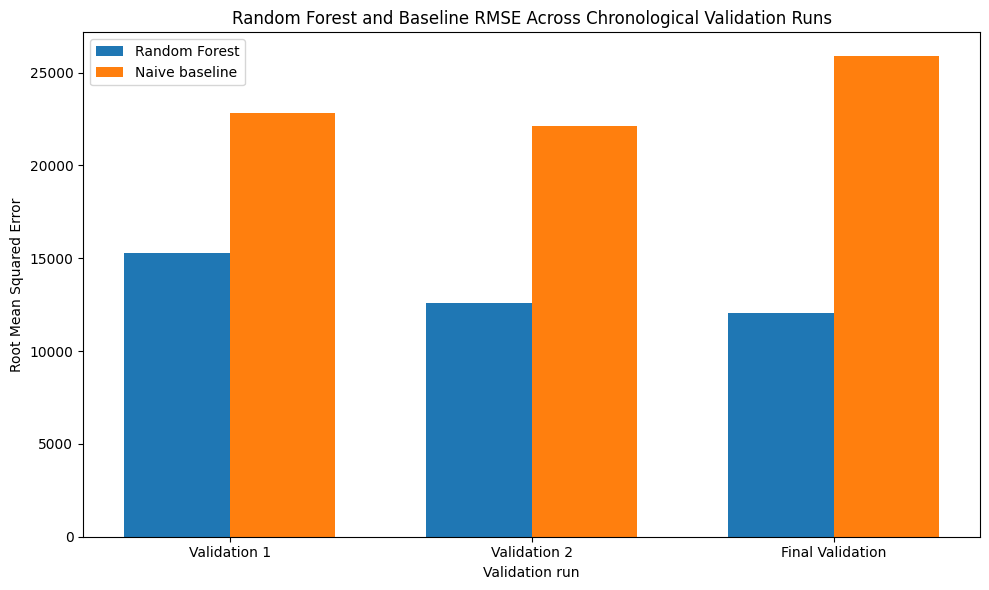

Saved: figure_rolling_validation_rmse.png


In [43]:
validation_plot_df = (
    rolling_validation_df[
        [
            "Validation_Run",
            "Random_Forest_RMSE",
            "Baseline_RMSE"
        ]
    ]
    .copy()
)

x_positions = np.arange(
    len(validation_plot_df)
)

bar_width = 0.35

plt.figure(
    figsize=(10, 6)
)

plt.bar(
    x_positions - bar_width / 2,
    validation_plot_df[
        "Random_Forest_RMSE"
    ],
    width=bar_width,
    label="Random Forest"
)

plt.bar(
    x_positions + bar_width / 2,
    validation_plot_df[
        "Baseline_RMSE"
    ],
    width=bar_width,
    label="Naive baseline"
)

plt.xticks(
    x_positions,
    validation_plot_df[
        "Validation_Run"
    ]
)

plt.title(
    "Random Forest and Baseline RMSE Across Chronological Validation Runs"
)

plt.xlabel(
    "Validation run"
)

plt.ylabel(
    "Root Mean Squared Error"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "figure_rolling_validation_rmse.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved: figure_rolling_validation_rmse.png"
)

In [44]:
validation_summary_df = pd.DataFrame({
    "Measure": [
        "Number of validation runs",
        "Average Random Forest MAE",
        "Average Random Forest RMSE",
        "Average Random Forest R2",
        "Average Random Forest WAPE (%)",
        "Lowest Random Forest WAPE (%)",
        "Highest Random Forest WAPE (%)",
        "Average MAE improvement (%)",
        "Average RMSE improvement (%)"
    ],
    "Value": [
        len(rolling_validation_df),
        rolling_validation_df[
            "Random_Forest_MAE"
        ].mean(),
        rolling_validation_df[
            "Random_Forest_RMSE"
        ].mean(),
        rolling_validation_df[
            "Random_Forest_R2"
        ].mean(),
        rolling_validation_df[
            "Random_Forest_WAPE_Percentage"
        ].mean(),
        rolling_validation_df[
            "Random_Forest_WAPE_Percentage"
        ].min(),
        rolling_validation_df[
            "Random_Forest_WAPE_Percentage"
        ].max(),
        rolling_validation_df[
            "MAE_Improvement_Percentage"
        ].mean(),
        rolling_validation_df[
            "RMSE_Improvement_Percentage"
        ].mean()
    ]
})

print("CHRONOLOGICAL VALIDATION SUMMARY")
print("=" * 70)

display(
    validation_summary_df.round(4)
)

validation_summary_df.to_csv(
    "chronological_validation_summary.csv",
    index=False
)

print(
    "\nSaved: chronological_validation_summary.csv"
)

CHRONOLOGICAL VALIDATION SUMMARY


,Measure,Value
0,Number of validation runs,3.0000
1,Average Random Forest MAE,7310.5928
2,Average Random Forest RMSE,13299.5480
3,Average Random Forest R2,0.9880
4,Average Random Forest WAPE (%),6.8471
5,Lowest Random Forest WAPE (%),6.1640
6,Highest Random Forest WAPE (%),7.9614
7,Average MAE improvement (%),44.6947
8,Average RMSE improvement (%),43.2457



Saved: chronological_validation_summary.csv


In [45]:
import os

expected_output_files = [
    "feature_importance_results.csv",
    "feature_importance_detailed.csv",
    "figure_feature_importance.png",
    "figure_wape_by_road.png",
    "wape_by_road_results.csv",
    "rolling_validation_results.csv",
    "chronological_validation_summary.csv",
    "figure_rolling_validation_rmse.png"
]

print("NOTEBOOK 05 OUTPUT CHECK")
print("=" * 70)

all_files_found = True

for filename in expected_output_files:
    if os.path.exists(filename):
        print(
            f"[FOUND] {filename} "
            f"({os.path.getsize(filename):,} bytes)"
        )
    else:
        print(f"[MISSING] {filename}")
        all_files_found = False

print("\nOutput check passed:", all_files_found)

NOTEBOOK 05 OUTPUT CHECK
[FOUND] feature_importance_results.csv (829 bytes)
[FOUND] feature_importance_detailed.csv (1,975 bytes)
[FOUND] figure_feature_importance.png (162,879 bytes)
[FOUND] figure_wape_by_road.png (149,688 bytes)
[FOUND] wape_by_road_results.csv (971 bytes)
[FOUND] rolling_validation_results.csv (1,056 bytes)
[FOUND] chronological_validation_summary.csv (417 bytes)
[FOUND] figure_rolling_validation_rmse.png (119,652 bytes)

Output check passed: True


In [46]:
import zipfile

zip_filename = (
    "05_Model_Interpretation_and_"
    "Robustness_Outputs.zip"
)

with zipfile.ZipFile(
    zip_filename,
    "w",
    zipfile.ZIP_DEFLATED
) as zip_file:

    for filename in expected_output_files:
        if os.path.exists(filename):
            zip_file.write(filename)

print(
    "Created:",
    zip_filename,
    f"({os.path.getsize(zip_filename):,} bytes)"
)

Created: 05_Model_Interpretation_and_Robustness_Outputs.zip (319,571 bytes)


In [47]:
from google.colab import files

files.download(
    "05_Model_Interpretation_and_"
    "Robustness_Outputs.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>